### Unsupervised Learning: Dimensionality Reduction

#### Principal Component Analysis (PCA) Implementation

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [14]:
X, y = make_classification(
    n_samples = 500,
    n_features=6,
    n_informative=4,
    n_redundant=2,
    random_state=42
)

print(X.shape)

(500, 6)


In [15]:
X_scaled = StandardScaler().fit_transform(X)

In [16]:
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

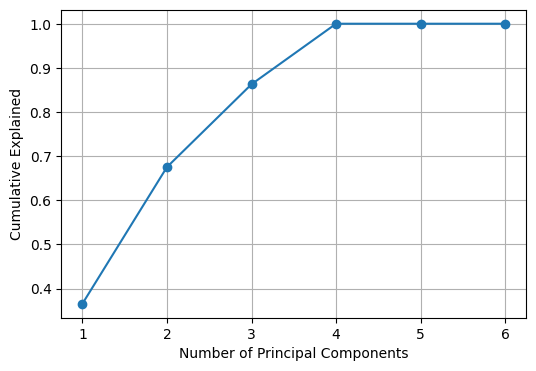

In [17]:
explained_var = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_var) + 1), explained_var, marker="o")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained")
plt.grid(True)
plt.show()

In [18]:
df_components = pd.DataFrame(
    pca.components_,
    columns=[f"Feature {i+1}" for i in range(X.shape[1])]
)

df_components.index = [f"PC{i+1}" for i in range(X.shape[1])]

df_components

,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6
PC1,-0.068614,0.567296,0.002389,0.586903,0.135849,0.557272
PC2,0.665262,0.256067,0.517338,0.231416,-0.117398,-0.396083
PC3,0.274225,0.192717,-0.099515,-0.348985,0.869440,-0.006400
PC4,-0.317219,-0.398168,0.772791,0.098026,0.317450,0.182335
PC5,0.613847,-0.511824,-0.121542,0.031573,-0.077110,0.582677
PC6,-0.009146,-0.393654,-0.332377,0.685270,0.324216,-0.399709


In [19]:
results = []

for n in range(1, X.shape[1] + 1):
    pca = PCA(n_components = n)
    X_reduced = pca.fit_transform(X_scaled)

    X_train, X_test, y_train, y_test = train_test_split(
        X_reduced, y, test_size = 0.3, random_state= 42
    )

    clf = LogisticRegression()
    clf.fit(X_train, y_train)
    predictions = clf.predict(X_test)

    acc = accuracy_score(y_test, predictions)

    results.append((n, acc, pca.explained_variance_ratio_.sum()))

In [24]:
df_acc = pd.DataFrame(results, columns=['n_components', 'accuracy', 'explained_variance'])

df_acc


,n_components,accuracy,explained_variance
0,1,0.620000,0.365554
1,2,0.686667,0.675176
2,3,0.740000,0.862795
3,4,0.746667,1.000000
4,5,0.746667,1.000000
5,6,0.746667,1.000000


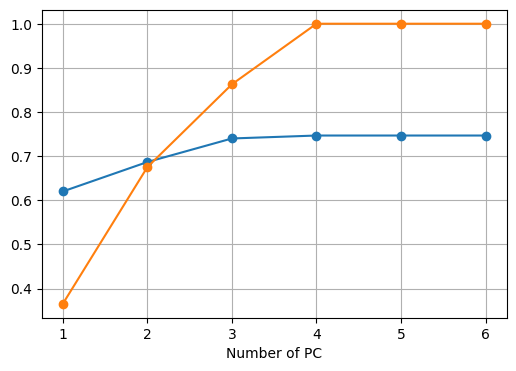

In [25]:
plt.figure(figsize=(6,4))
plt.plot(df_acc['n_components'], df_acc['accuracy'], marker="o", label="Accuracy")
plt.plot(df_acc['n_components'], df_acc['explained_variance'], marker="o", label="Explained Variance")
plt.xlabel('Number of PC')
plt.grid(True)
plt.show()